# Black body Radiation  
Every physical body spontaneously and continuously emits electromagnetic radiation.  
A body that absorbs all the radiation incedent upon it irrespective of the frequency is called black body, i.e. a = e = 1.  
To explain the spectrum of a black body, the following laws were introduced  

In [1]:
import math
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
from adjustText import adjust_text
from IPython.display import display, Latex
from scipy.constants import k    #boltzmann constant
from scipy.constants import h    #plank's constant
from scipy.constants import c    #speed of light
from scipy.constants import sigma    #stefan's constant
from scipy.constants import Wien as b    #wien's constant

In [2]:
#inputs
T = np.linspace(500,1000,5)  #temperature range in Kelvin
T0 = 875  #temperature range in Kelvin
W = np.linspace(0.1,30,600) *(10**(-6)) #wavelength in m
laws = ['Raleigh-Jeans law', 'Wien\'s law', 'Planck\'s law']

### 1. Raleigh - Jeans law  
Considers light emission as the classical phenomena  
Energy per unit volume in the frequency range from $\nu$ to $\nu+d\nu$ is  
$$
u(\nu)d\nu = \frac{8\pi kT}{c^3}{\nu}^2d\nu
$$
$$
u(\lambda)\ d\lambda = \frac{8\pi kT}{\lambda^4} d\lambda
$$

In [3]:
#raleigh-jeans law
A = 8*np.pi*k
def u_rj(w, temp):
    return A*temp/(w**4)

### 2. Wien's distribution law  
Uses thermodynamics  
Energy per unit volume in the frequency range from $\nu$ to $\nu+d\nu$ is  

$$
u(\nu)d\nu = \frac{8\pi h}{c^3}{e^{-(\frac{h\nu}{kT})}}{\nu}^3d\nu
$$

$$
u(\lambda)d\lambda = \frac{8\pi hc}{\lambda^5}{e^{-(\frac{hc}{\lambda kT})}}d\lambda
$$

In [4]:
#wien's distribution law
B = (h*c)/k
def u_w(w, temp):
    return 8*np.pi*h*c*np.exp(-B/(w*temp))/(w**5)

### 3. Planck's law  
Considers light emission as the quantum phenomena  
Energy per unit volume in the frequency range from $\nu$ to $\nu+d\nu$ is  

$$
u(\nu)d\nu = \frac{8\pi h}{c^3}\frac{{\nu}^3d\nu}{e^{(\frac{h\nu}{kT})}-1}
$$

$$
u(\lambda)d\lambda = \frac{8\pi hc}{\lambda^5}\frac{1}{e^{(\frac{hc}{\lambda kT})}-1}d\lambda
$$

In [5]:
#Planck's law
B = (h*c)/k
def u_p(w, temp):
    return (8*np.pi*h*c/(np.exp(B/(w*temp))-1))/(w**5)

In [6]:
#calculating values of laws for temp and wavelength range
data = {}
for law in laws:
    data_a = {}
    for temp in T:
        data_t = []
        for w in W:
            if law=='Raleigh-Jeans law' : res = u_rj(w, temp)
            elif law=='Wien\'s law' : res = u_w(w, temp)
            elif law=='Planck\'s law' : res = u_p(w, temp)
            else: print("Error")
            data_t.append(res)
        data_a[temp] = data_t
    data[law] = data_a

In [ ]:
print(data)

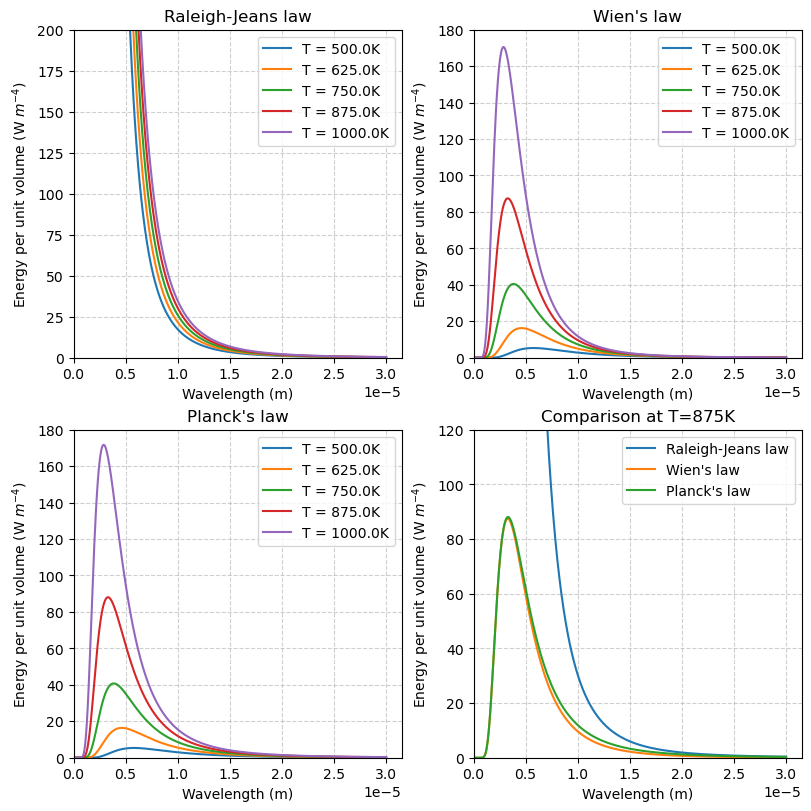

In [8]:
#plotting graphs
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(8,8), constrained_layout=True)
axes = axes.flatten()
#linestyles = ['-', '-', (0,(5,5))]  #for dashed line for Plank's Law

for i, ax in enumerate(axes):
    for temp in T:
        ax.plot(W, data[list(data.keys())[i]][temp], label=f'T = {temp}K')
    if i==2:
        break
        
#comparison of distribution laws plot
for i, law in enumerate(list(data.keys())):
    axes[3].plot(W, data[law][T0], label=f'{law}', linestyle='-')
    
#subplots formatting
y_lim = [200, 180, 180, 120]
for i, ax in enumerate(axes):
    
    ax.grid(True, linestyle='--', alpha=0.6)       # Enable grid
    ax.set_xlabel("Wavelength (m)")               # Common X label
    ax.set_ylabel(r'Energy per unit volume (W $m^{-4}$)')      # Common Y label
    if i<3: ax.set_title(f"{list(data.keys())[i]}")       #title
    else : ax.set_title(f"Comparison at T={T0}K")
    ax.tick_params(axis='both', labelsize=10)      # Tick label size
    ax.set_xlim(0)                             # X-axis range
    ax.set_ylim(0, y_lim[i])                             # Y-axis range
    ax.legend()

plt.show()

### 4. Wien's displacement law
$$
\lambda_{max} T = b
$$  
where b is Wien's constant = 2898 $\mu m K$

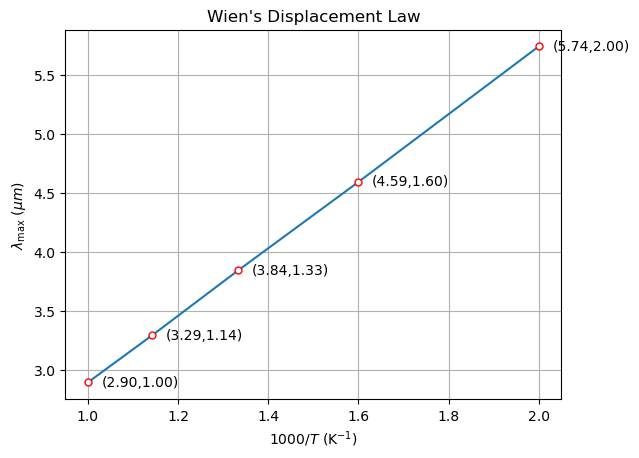

In [9]:
#finding wavelength (for each temperature) for which Energy per unit volume is maximum
W_max = []
for temp in T:
    y = np.array(data["Wien's law"][temp])
    idx = np.argmax(y)
    W_max.append(W[idx] * 1e6)  #wavelength in um
T_reciprocal = 1000/T

#plotting W_max v/s 1/T
plt.plot(T_reciprocal, W_max, marker='o', markersize=5, mec='r', mfc='w', alpha=1)

#plot formatting
plt.grid(True)
plt.xlabel(r'$1000/T\ (\mathrm{K}^{-1})$')
plt.ylabel(r'$\lambda_{\max}\ (\mu m)$')
plt.title('Wien\'s Displacement Law')

#adding label to points
for i in range(len(W_max)):
    plt.text(T_reciprocal[i]+0.03, W_max[i]-0.03, f'({W_max[i]:.2f},{T_reciprocal[i]:.2f})')


plt.show()

In [79]:
#calculating Wien's constant
straight_line = np.polyfit(T_reciprocal, W_max, 1) # 1 = degree of polynomial i.e. straight line here
b_calculated, intercept = straight_line
b_calculated *= 1e-3    #scaling upto SI units
error = abs(b_calculated - b)*100/b
#display(Latex(r"$b_{calculated}$"), b_calculated)
print(f'Calculated value of Wien\'s constant = {b_calculated}')
print(f'Theorectical value of Wien\'s constant = {b}')
print(f'Error = {error:.2f}%')

Calculated value of Wien's constant = 0.0028453974478253826
Theorectical value of Wien's constant = 0.002897771955
Error = 1.81%


### 5. Stefan's law
Flux $F$ = $\sigma T^4$  
For unit area and unit sec, energy emitted $E$ = $\frac{U c}{4}$    
where $\sigma$ is Stefan's constant = $ 5.67 \times 10^{-8} W m^{-2} K^{-4} $  

Energy per unit volume  

$$
U = \int_{0}^{\infty} u(\lambda)d\lambda = \int_{0}^{\infty} \frac{8\pi hc}{\lambda^5}\frac{1}{e^{(\frac{hc}{\lambda kT})}-1} d\lambda
$$

Calculating area under the curve of Plank's law using Trapezoidal rule: 

$$
U = \frac{\Delta \lambda}{2} (u_0 + 2u_1 + 2u_2 + ... + 2u_{n-1} + u_n)
$$

$$
\Delta \lambda = \frac{b-a}{n}
$$

where $a$ and $b$ are lower and upper limit of the integral respectively

Taking $u_1 \approx u_n \approx 0$, we get
$$
U = \frac{\Delta \lambda}{2} (2u_1 + 2u_2 + ... + 2u_{n-1}) \\
= ({\lambda}_2 - {\lambda}_1) (u_1 + u_2 + ... + u_{n-1}) \\
= ({\lambda}_2 - {\lambda}_1) {\Sigma}_{1}^{n-1} u_k
$$

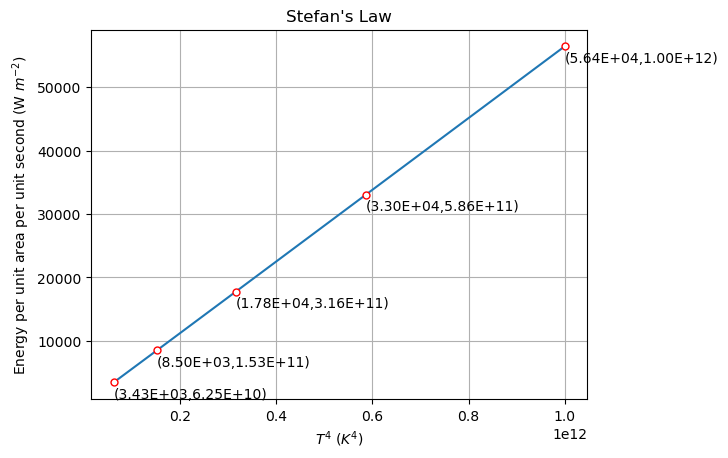

In [15]:
#calculating U for every temp in T
u_sum = []
for temp in T:    #calculating sum of u for every temp in T
    u_sum.append(sum(data['Planck\'s law'][temp]))
E = [(W[1]-W[0])*c*u/4 for u in u_sum]

#plotting U v/s T^4 graph
plt.plot(T**4, E, marker='o', markersize=5, mec='r', mfc='w', alpha=1)

#plot formatting
plt.grid(True)
plt.xlabel(r'$T^4$ ($K^4$)')
plt.ylabel(r'Energy per unit area per unit second (W $m^{-2}$)')
plt.title('Stefan\'s Law')

#adding label to points
for i, temp in enumerate(T**4):
    plt.text(temp+0.3, E[i]-2500,f'({E[i]:.2E},{temp:.2E})')

plt.show()

In [16]:
#calculating Stefan's constant
straight_line = np.polyfit(T**4, E, 1) # 1 = degree of polynomial i.e. straight line here
sigma_calculated, intercept = straight_line
error = abs(sigma_calculated - sigma)*100/sigma
#display(Latex(r"$b_{calculated}$"), b_calculated)
print(f'Calculated value of Wien\'s constant = {sigma_calculated}')
print(f'Theorectical value of Wien\'s constant = {sigma}')
print(f'Error = {error:.2f}%')

Calculated value of Wien's constant = 5.65461067463154e-08
Theorectical value of Wien's constant = 5.670374419e-08
Error = 0.28%
